## Q2 — How big are the earrings?


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

f  = 8.0        # mm
do = 720.0      # mm — distance from lens to earring plane
px = 0.0022     # mm — pixel pitch (2.2 µm)

di   = (f * do) / (do - f)
mag  = di / do
scale = px / mag   # mm per pixel in the real world

print(f'Image distance  d_i  = {di:.4f} mm')
print(f'Magnification   m    = {mag:.6f}  (i.e. 1 / {1/mag:.1f})')
print(f'Scale                = {scale:.5f} mm/pixel')
print(f'                     = {scale*1000:.3f} µm/pixel')

Image distance  d_i  = 8.0899 mm
Magnification   m    = 0.011236  (i.e. 1 / 89.0)
Scale                = 0.19580 mm/pixel
                     = 195.800 µm/pixel


## Step 3 - Measure the earrings in pixels

The earrings are gold on a white background, so isolating them with a simple brightness threshold should work well. I'll find the contours of the two earrings and fit a minimum enclosing circle to each — the diameter of that circle is the outer span of the earring in pixels.

Image size: 1024 × 1024 px


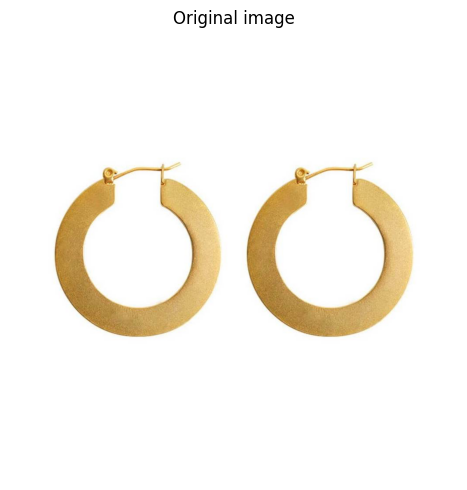

In [2]:
img_path = os.path.join('..', 'question', 'earrings.jpg')
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(f'Image size: {img.shape[1]} × {img.shape[0]} px')

plt.figure(figsize=(6, 5))
plt.imshow(img_rgb)
plt.title('Original image')
plt.axis('off')
plt.tight_layout()
plt.show()

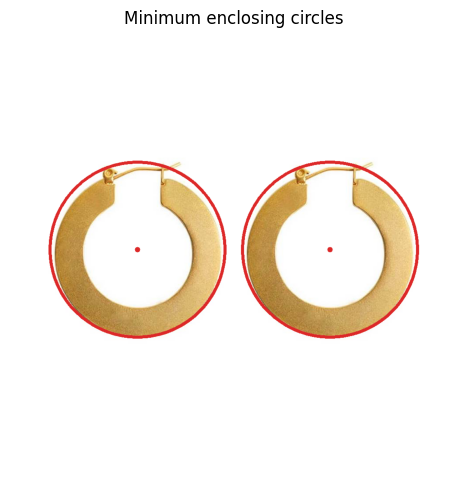

Earring 1: diameter = 400.2 px
Earring 2: diameter = 400.2 px


In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# background is near-white, so invert threshold to get earring mask
_, mask = cv2.threshold(gray, 210, 255, cv2.THRESH_BINARY_INV)

# clean up small noise and fill inner holes
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)

# find the two largest blobs
cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:2]

vis = img_rgb.copy()
diameters_px = []

for cnt in cnts:
    (cx, cy), r = cv2.minEnclosingCircle(cnt)
    diameters_px.append(2 * r)
    cv2.circle(vis, (int(cx), int(cy)), int(r), (220, 40, 40), 5)
    cv2.circle(vis, (int(cx), int(cy)), 6, (220, 40, 40), -1)

plt.figure(figsize=(6, 5))
plt.imshow(vis)
plt.title('Minimum enclosing circles')
plt.axis('off')
plt.tight_layout()
plt.savefig('q2_earring_measurement.png', dpi=150)
plt.show()

for i, d in enumerate(diameters_px):
    print(f'Earring {i+1}: diameter = {d:.1f} px')

In [4]:
print('=' * 40)
print('Physical size results')
print('=' * 40)
for i, d_px in enumerate(diameters_px):
    d_mm = d_px * scale
    print(f'  Earring {i+1}: {d_px:.1f} px  →  {d_mm:.1f} mm  ({d_mm/10:.2f} cm)')

avg = np.mean(diameters_px) * scale
print(f'\n  Average outer diameter ≈ {avg:.1f} mm = {avg/10:.2f} cm')

Physical size results
  Earring 1: 400.2 px  →  78.4 mm  (7.84 cm)
  Earring 2: 400.2 px  →  78.4 mm  (7.84 cm)

  Average outer diameter ≈ 78.4 mm = 7.84 cm
